In [1]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

import joblib

In [141]:
# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load events dataset
events = pd.read_csv("../data/01-raw/events.csv")

In [3]:
# Preview events dataset
print(events.shape)
events.head()

(30000, 18)


,event_id,user_id,session_id,listing_id,event_time,device_type,traffic_source,room_type,city,price,price_log,demand_score,availability_ratio,impression,click,detail_view,save,contact
0,1,35015,587281,12775106,2025-03-10 01:50:00,mobile,email,Entire home/apt,Queens,120,4.795791,0.03,0.000000,1,1,0,0,0
1,2,89720,182859,304799,2025-02-23 07:15:00,mobile,organic,Entire home/apt,Manhattan,150,5.017280,1.43,0.005479,1,1,1,1,1
2,3,76186,894861,30120067,2025-03-26 04:40:00,tablet,organic,Shared room,Bronx,50,3.931826,10.08,0.660274,1,1,1,0,1
3,4,74430,354595,34387952,2025-03-08 03:28:00,desktop,organic,Entire home/apt,Manhattan,250,5.525453,0.88,0.167123,1,1,1,1,1
4,5,59185,360425,8754339,2025-02-27 08:03:00,mobile,email,Shared room,Manhattan,60,4.110874,0.00,0.000000,1,0,0,0,0


In [4]:
# Check target distribution
events["contact"].value_counts()

contact
0    21200
1     8800
Name: count, dtype: int64

In [5]:
# Check target percentage
events["contact"].value_counts(normalize=True)

contact
0    0.706667
1    0.293333
Name: proportion, dtype: float64

In [6]:
# Select modeling columns
model_df = events[
    [
        "device_type",
        "traffic_source",
        "room_type",
        "city",
        "price_log",
        "demand_score",
        "availability_ratio",
        "click",
        "detail_view",
        "save",
        "contact"
    ]
].copy()

In [7]:
# Preview modeling dataset
print(model_df.shape)
model_df.head()

(30000, 11)


,device_type,traffic_source,room_type,city,price_log,demand_score,availability_ratio,click,detail_view,save,contact
0,mobile,email,Entire home/apt,Queens,4.795791,0.03,0.000000,1,0,0,0
1,mobile,organic,Entire home/apt,Manhattan,5.017280,1.43,0.005479,1,1,1,1
2,tablet,organic,Shared room,Bronx,3.931826,10.08,0.660274,1,1,0,1
3,desktop,organic,Entire home/apt,Manhattan,5.525453,0.88,0.167123,1,1,1,1
4,mobile,email,Shared room,Manhattan,4.110874,0.00,0.000000,0,0,0,0


In [8]:
# Split features and target
X = model_df.drop(columns="contact")
y = model_df["contact"]

In [9]:
X

,device_type,traffic_source,room_type,city,price_log,demand_score,availability_ratio,click,detail_view,save
0,mobile,email,Entire home/apt,Queens,4.795791,0.03,0.000000,1,0,0
1,mobile,organic,Entire home/apt,Manhattan,5.017280,1.43,0.005479,1,1,1
2,tablet,organic,Shared room,Bronx,3.931826,10.08,0.660274,1,1,0
3,desktop,organic,Entire home/apt,Manhattan,5.525453,0.88,0.167123,1,1,1
4,mobile,email,Shared room,Manhattan,4.110874,0.00,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...
29995,mobile,paid,Entire home/apt,Brooklyn,4.543295,0.00,0.000000,0,0,0
29996,desktop,organic,Private room,Brooklyn,4.454347,177.60,0.221918,1,1,1
29997,mobile,organic,Private room,Brooklyn,4.110874,19.36,0.126027,0,0,0
29998,mobile,paid,Entire home/apt,Manhattan,5.866468,9.45,0.035616,0,0,0


In [10]:
y

0        0
1        1
2        1
3        1
4        0
        ..
29995    0
29996    0
29997    0
29998    0
29999    0
Name: contact, Length: 30000, dtype: int64

In [11]:
# Define categorical columns
categorical_features = [
    "device_type",
    "traffic_source",
    "room_type",
    "city"
]

# Define numeric columns
numeric_features = [
    "price_log",
    "demand_score",
    "availability_ratio",
    "click",
    "detail_view",
    "save"
]

In [12]:
# Split train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# Check split shapes
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(24000, 10) (6000, 10)
(24000,) (6000,)


In [14]:
# Create numeric transformer
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [16]:
# Create categorical transformer
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [17]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Logistic Regression

In [18]:
# Create logistic regression pipeline
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

In [19]:
# Train logistic regression model
log_reg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
# Predict with logistic regression
y_pred_log = log_reg_pipeline.predict(X_test)
y_prob_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [21]:
# Evaluate logistic regression
log_results = {
    "accuracy": accuracy_score(y_test, y_pred_log),
    "precision": precision_score(y_test, y_pred_log),
    "recall": recall_score(y_test, y_pred_log),
    "f1": f1_score(y_test, y_pred_log),
    "roc_auc": roc_auc_score(y_test, y_prob_log),
    "pr_auc": average_precision_score(y_test, y_prob_log)
}

log_results

{'accuracy': 0.8225,
 'precision': 0.6230088495575221,
 'recall': 1.0,
 'f1': 0.7677208287895311,
 'roc_auc': 0.90332955885506,
 'pr_auc': 0.7001442771278149}

In [22]:
# Print classification report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86      4240
           1       0.62      1.00      0.77      1760

    accuracy                           0.82      6000
   macro avg       0.81      0.87      0.81      6000
weighted avg       0.89      0.82      0.83      6000



### Random Forest

In [23]:
# Create random forest pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            class_weight="balanced_subsample"
        ))
    ]
)

In [24]:
# Train random forest model
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
# Predict with random forest
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [26]:
# Evaluate random forest
rf_results = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_prob_rf),
    "pr_auc": average_precision_score(y_test, y_prob_rf)
}

rf_results

{'accuracy': 0.8223333333333334,
 'precision': 0.6232244318181818,
 'recall': 0.9971590909090909,
 'f1': 0.7670454545454546,
 'roc_auc': 0.908054111277873,
 'pr_auc': 0.7116598034651309}

In [27]:
# Print classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86      4240
           1       0.62      1.00      0.77      1760

    accuracy                           0.82      6000
   macro avg       0.81      0.87      0.81      6000
weighted avg       0.89      0.82      0.83      6000



In [28]:
# Compare baseline model results
results_df = pd.DataFrame([log_results, rf_results], index=["logistic_regression", "random_forest"])
results_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
logistic_regression,0.822500,0.623009,1.000000,0.767721,0.903330,0.700144
random_forest,0.822333,0.623224,0.997159,0.767045,0.908054,0.711660


### Try other models

In [29]:
# Import additional models
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

In [30]:
# Create Extra Trees pipeline
et_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [31]:
# Train Extra Trees model
et_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
# Predict with Extra Trees
y_pred_et = et_pipeline.predict(X_test)
y_prob_et = et_pipeline.predict_proba(X_test)[:, 1]

In [33]:
# Evaluate Extra Trees
et_results = {
    "accuracy": accuracy_score(y_test, y_pred_et),
    "precision": precision_score(y_test, y_pred_et),
    "recall": recall_score(y_test, y_pred_et),
    "f1": f1_score(y_test, y_pred_et),
    "roc_auc": roc_auc_score(y_test, y_prob_et),
    "pr_auc": average_precision_score(y_test, y_prob_et)
}

et_results

{'accuracy': 0.8228333333333333,
 'precision': 0.6234502302515055,
 'recall': 1.0,
 'f1': 0.7680558586078987,
 'roc_auc': 0.9001699855274442,
 'pr_auc': 0.6848907599806033}

### Gradient Boosting

In [42]:
# Create Gradient Boosting pipeline
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

In [43]:
# Train Gradient Boosting model
gb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
# Predict with Gradient Boosting
y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

In [45]:
# Evaluate Gradient Boosting
gb_results = {
    "accuracy": accuracy_score(y_test, y_pred_gb),
    "precision": precision_score(y_test, y_pred_gb),
    "recall": recall_score(y_test, y_pred_gb),
    "f1": f1_score(y_test, y_pred_gb),
    "roc_auc": roc_auc_score(y_test, y_prob_gb),
    "pr_auc": average_precision_score(y_test, y_prob_gb)
}

gb_results

{'accuracy': 0.834,
 'precision': 0.6753902662993572,
 'recall': 0.8357954545454546,
 'f1': 0.7470797359065515,
 'roc_auc': 0.9096064268867925,
 'pr_auc': 0.7084104025508287}

In [46]:
# Transform train and test data for Hist Gradient Boosting
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [47]:
# Create Hist Gradient Boosting model
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=200,
    random_state=42
)

In [48]:
# Train Hist Gradient Boosting model
hgb_model.fit(X_train_processed, y_train)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,200
,max_leaf_nodes,31
,max_depth,6
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [49]:
# Predict with Hist Gradient Boosting
y_pred_hgb = hgb_model.predict(X_test_processed)
y_prob_hgb = hgb_model.predict_proba(X_test_processed)[:, 1]

In [50]:
# Evaluate Hist Gradient Boosting
hgb_results = {
    "accuracy": accuracy_score(y_test, y_pred_hgb),
    "precision": precision_score(y_test, y_pred_hgb),
    "recall": recall_score(y_test, y_pred_hgb),
    "f1": f1_score(y_test, y_pred_hgb),
    "roc_auc": roc_auc_score(y_test, y_prob_hgb),
    "pr_auc": average_precision_score(y_test, y_prob_hgb)
}

hgb_results

{'accuracy': 0.8341666666666666,
 'precision': 0.6741010468821119,
 'recall': 0.8414772727272727,
 'f1': 0.7485468789486985,
 'roc_auc': 0.9074827133361921,
 'pr_auc': 0.709474988818448}

In [51]:
# Compare all model results
results_df = pd.DataFrame(
    [
        log_results,
        rf_results,
        et_results,
        gb_results,
        hgb_results
    ],
    index=[
        "logistic_regression",
        "random_forest",
        "extra_trees",
        "gradient_boosting",
        "hist_gradient_boosting"
    ]
)

results_df.sort_values("pr_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc,pr_auc
random_forest,0.822333,0.623224,0.997159,0.767045,0.908054,0.711660
hist_gradient_boosting,0.834167,0.674101,0.841477,0.748547,0.907483,0.709475
gradient_boosting,0.834000,0.675390,0.835795,0.747080,0.909606,0.708410
logistic_regression,0.822500,0.623009,1.000000,0.767721,0.903330,0.700144
extra_trees,0.822833,0.623450,1.000000,0.768056,0.900170,0.684891


In [52]:
# Identify best model
best_model_name = results_df["pr_auc"].idxmax()
best_model_name

'random_forest'

### Try feature engineering on model df

In [80]:
# Create a copy of model_df
model_df_fe = model_df.copy()

In [81]:
# Preview modeling dataset copy
print(model_df_fe.shape)
model_df_fe.head()

(30000, 11)


,device_type,traffic_source,room_type,city,price_log,demand_score,availability_ratio,click,detail_view,save,contact
0,mobile,email,Entire home/apt,Queens,4.795791,0.03,0.000000,1,0,0,0
1,mobile,organic,Entire home/apt,Manhattan,5.017280,1.43,0.005479,1,1,1,1
2,tablet,organic,Shared room,Bronx,3.931826,10.08,0.660274,1,1,0,1
3,desktop,organic,Entire home/apt,Manhattan,5.525453,0.88,0.167123,1,1,1,1
4,mobile,email,Shared room,Manhattan,4.110874,0.00,0.000000,0,0,0,0


In [82]:
# Create log-transformed demand score
model_df_fe["demand_score_log"] = np.log1p(model_df_fe["demand_score"])

In [84]:
# Create room and city interaction
model_df_fe["room_city"] = (
    model_df_fe["room_type"].astype(str) + "_" + model_df_fe["city"].astype(str)
)

In [109]:
# Recreate availability bucket
model_df_fe["availability_bucket"] = pd.cut(
    model_df_fe["availability_ratio"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.00],
    labels=["very_low", "low", "medium", "high"]
)

In [86]:
# Create city median price log
city_median_price_log = model_df_fe.groupby("city")["price_log"].median().to_dict()

model_df_fe["city_median_price_log"] = model_df_fe["city"].map(city_median_price_log)

In [87]:
# Create relative price to city median
model_df_fe["price_log_diff_from_city"] = (
    model_df_fe["price_log"] - model_df_fe["city_median_price_log"]
)

In [88]:
# Create relative price bucket
model_df_fe["relative_price_bucket"] = pd.cut(
    model_df_fe["price_log_diff_from_city"],
    bins=[-10, -0.25, 0.25, 10],
    labels=["below_city", "near_city", "above_city"]
)

In [89]:
# Create listing attractiveness score
model_df_fe["listing_attractiveness_score"] = (
    0.4 * model_df_fe["demand_score_log"]
    + 0.3 * (1 / (1 + np.exp(model_df_fe["price_log_diff_from_city"])))
    + 0.3 * model_df_fe["availability_ratio"]
)

In [90]:
# Check missing values
model_df_fe.isnull().sum()

device_type                     0
traffic_source                  0
room_type                       0
city                            0
price_log                       0
demand_score                    0
availability_ratio              0
click                           0
detail_view                     0
save                            0
contact                         0
demand_score_log                0
room_city                       0
city_median_price_log           0
price_log_diff_from_city        0
relative_price_bucket           0
listing_attractiveness_score    0
dtype: int64

In [91]:
# Split engineered features and target
X_fe = model_df_fe.drop(columns="contact")
y_fe = model_df_fe["contact"]

In [118]:
# Define updated categorical features
categorical_features_fe = [
    "device_type",
    "traffic_source",
    "room_type",
    "city",
    "room_city",
    "relative_price_bucket"
]

In [119]:
# Define updated numeric features
numeric_features_fe = [
    "price_log",
    "demand_score",
    "demand_score_log",
    "availability_ratio",
    "price_log_diff_from_city",
    "listing_attractiveness_score",
    "click",
    "detail_view",
    "save"
]

In [120]:
# Split train and test sets
X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

In [121]:
# Build numeric transformer
numeric_transformer_fe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [122]:
# Build categorical transformer
categorical_transformer_fe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [123]:
# Build updated preprocessor
preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_fe, numeric_features_fe),
        ("cat", categorical_transformer_fe, categorical_features_fe)
    ]
)

In [124]:
# Build updated random forest pipeline
rf_pipeline_fe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            class_weight="balanced_subsample"
        ))
    ]
)

In [125]:
# Train updated random forest
rf_pipeline_fe.fit(X_fe_train, y_fe_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [126]:
# Predict with updated random forest
y_pred_rf_fe = rf_pipeline_fe.predict(X_fe_test)
y_prob_rf_fe = rf_pipeline_fe.predict_proba(X_fe_test)[:, 1]

In [127]:
# Evaluate updated random forest
rf_fe_results = {
    "accuracy": accuracy_score(y_fe_test, y_pred_rf_fe),
    "precision": precision_score(y_fe_test, y_pred_rf_fe),
    "recall": recall_score(y_fe_test, y_pred_rf_fe),
    "f1": f1_score(y_fe_test, y_pred_rf_fe),
    "roc_auc": roc_auc_score(y_fe_test, y_prob_rf_fe),
    "pr_auc": average_precision_score(y_fe_test, y_prob_rf_fe)
}

rf_fe_results

{'accuracy': 0.8225,
 'precision': 0.6249550521395182,
 'recall': 0.9875,
 'f1': 0.7654701607575424,
 'roc_auc': 0.9083501956475128,
 'pr_auc': 0.7123926574265008}

In [128]:
# Transform features for Hist Gradient Boosting
X_fe_train_processed = preprocessor_fe.fit_transform(X_fe_train)
X_fe_test_processed = preprocessor_fe.transform(X_fe_test)

In [129]:
# Build updated Hist Gradient Boosting model
hgb_model_fe = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=200,
    random_state=42
)

In [130]:
# Train updated Hist Gradient Boosting model
hgb_model_fe.fit(X_fe_train_processed, y_fe_train)

,loss,'log_loss'
,learning_rate,0.05
,max_iter,200
,max_leaf_nodes,31
,max_depth,6
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [131]:
# Predict with updated Hist Gradient Boosting model
y_pred_hgb_fe = hgb_model_fe.predict(X_fe_test_processed)
y_prob_hgb_fe = hgb_model_fe.predict_proba(X_fe_test_processed)[:, 1]

In [132]:
# Evaluate updated Hist Gradient Boosting model
hgb_fe_results = {
    "accuracy": accuracy_score(y_fe_test, y_pred_hgb_fe),
    "precision": precision_score(y_fe_test, y_pred_hgb_fe),
    "recall": recall_score(y_fe_test, y_pred_hgb_fe),
    "f1": f1_score(y_fe_test, y_pred_hgb_fe),
    "roc_auc": roc_auc_score(y_fe_test, y_prob_hgb_fe),
    "pr_auc": average_precision_score(y_fe_test, y_prob_hgb_fe)
}

hgb_fe_results

{'accuracy': 0.8331666666666667,
 'precision': 0.6728929384965832,
 'recall': 0.8392045454545455,
 'f1': 0.7469026548672566,
 'roc_auc': 0.9077380601415095,
 'pr_auc': 0.7102335817343051}

In [133]:
# Compare original and engineered top models
feature_upgrade_results_df = pd.DataFrame(
    [
        rf_results,
        hgb_results,
        rf_fe_results,
        hgb_fe_results
    ],
    index=[
        "random_forest_original",
        "hist_gradient_boosting_original",
        "random_forest_engineered",
        "hist_gradient_boosting_engineered"
    ]
)

feature_upgrade_results_df.sort_values("pr_auc", ascending=False)

,accuracy,precision,recall,f1,roc_auc,pr_auc
random_forest_engineered,0.822500,0.624955,0.987500,0.765470,0.908350,0.712393
random_forest_original,0.822333,0.623224,0.997159,0.767045,0.908054,0.711660
hist_gradient_boosting_engineered,0.833167,0.672893,0.839205,0.746903,0.907738,0.710234
hist_gradient_boosting_original,0.834167,0.674101,0.841477,0.748547,0.907483,0.709475


### Threshold

In [134]:
# Preview predicted probabilities
y_prob_rf_fe[:10]

array([0.86104667, 0.00281641, 0.73159717, 0.07958014, 0.00624546,
       0.69352625, 0.00620976, 0.00573811, 0.00338919, 0.08697855])

In [135]:
# Define thresholds to test
thresholds = np.arange(0.10, 0.91, 0.05)
thresholds

array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
       0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 ])

In [136]:
# Evaluate model across thresholds
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf_fe >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_fe_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_fe_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_fe_test, y_pred_threshold, zero_division=0)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,precision,recall,f1
0,0.10,0.610899,1.000000,0.758457
1,0.15,0.623009,1.000000,0.767721
2,0.20,0.623009,1.000000,0.767721
3,0.25,0.623009,1.000000,0.767721
4,0.30,0.622875,0.999432,0.767452
5,0.35,0.623317,0.999432,0.767787
6,0.40,0.622869,0.996591,0.766608
7,0.45,0.623132,0.994886,0.766302
8,0.50,0.624955,0.987500,0.765470
9,0.55,0.632051,0.961364,0.762677


In [137]:
# Sort threshold results by F1 score
threshold_results_df.sort_values("f1", ascending=False)

,threshold,precision,recall,f1
5,0.35,0.623317,0.999432,0.767787
3,0.25,0.623009,1.000000,0.767721
1,0.15,0.623009,1.000000,0.767721
2,0.20,0.623009,1.000000,0.767721
4,0.30,0.622875,0.999432,0.767452
6,0.40,0.622869,0.996591,0.766608
7,0.45,0.623132,0.994886,0.766302
8,0.50,0.624955,0.987500,0.765470
9,0.55,0.632051,0.961364,0.762677
0,0.10,0.610899,1.000000,0.758457


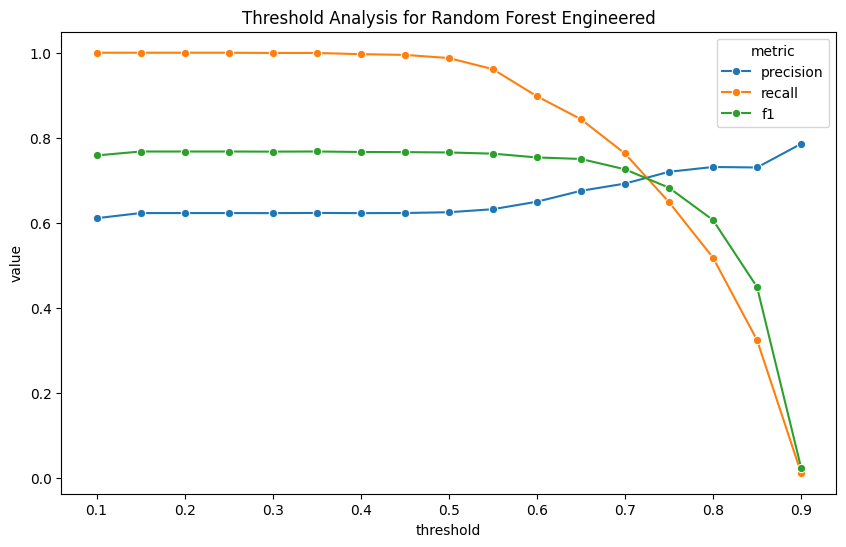

In [142]:
# Plot threshold metrics
threshold_plot_df = threshold_results_df.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=threshold_plot_df, x="threshold", y="value", hue="metric", marker="o")
plt.title("Threshold Analysis for Random Forest Engineered")
plt.show()

In [143]:
# Find best threshold by F1 score
best_threshold_row = threshold_results_df.sort_values("f1", ascending=False).head(1)
best_threshold_row

,threshold,precision,recall,f1
5,0.35,0.623317,0.999432,0.767787


In [145]:
# Save best threshold
best_threshold = best_threshold_row["threshold"].iloc[0]
best_threshold

np.float64(0.3500000000000001)

In [146]:
# Generate predictions using best threshold
y_pred_best_threshold = (y_prob_rf_fe >= best_threshold).astype(int)

In [147]:
# Evaluate model at best threshold
best_threshold_results = {
    "threshold": best_threshold,
    "accuracy": accuracy_score(y_fe_test, y_pred_best_threshold),
    "precision": precision_score(y_fe_test, y_pred_best_threshold, zero_division=0),
    "recall": recall_score(y_fe_test, y_pred_best_threshold, zero_division=0),
    "f1": f1_score(y_fe_test, y_pred_best_threshold, zero_division=0),
    "roc_auc": roc_auc_score(y_fe_test, y_prob_rf_fe),
    "pr_auc": average_precision_score(y_fe_test, y_prob_rf_fe)
}

best_threshold_results

{'threshold': np.float64(0.3500000000000001),
 'accuracy': 0.8226666666666667,
 'precision': 0.6233167965981573,
 'recall': 0.9994318181818181,
 'f1': 0.7677869925796595,
 'roc_auc': 0.9083501956475128,
 'pr_auc': 0.7123926574265008}

In [149]:
# Compare default and tuned threshold results
default_threshold_results = {
    "threshold": 0.50,
    "accuracy": rf_fe_results["accuracy"],
    "precision": rf_fe_results["precision"],
    "recall": rf_fe_results["recall"],
    "f1": rf_fe_results["f1"],
    "roc_auc": rf_fe_results["roc_auc"],
    "pr_auc": rf_fe_results["pr_auc"]
}

threshold_comparison_df = pd.DataFrame(
    [default_threshold_results, best_threshold_results],
    index=["default_threshold", "best_threshold"]
)

threshold_comparison_df

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
default_threshold,0.50,0.822500,0.624955,0.987500,0.765470,0.90835,0.712393
best_threshold,0.35,0.822667,0.623317,0.999432,0.767787,0.90835,0.712393


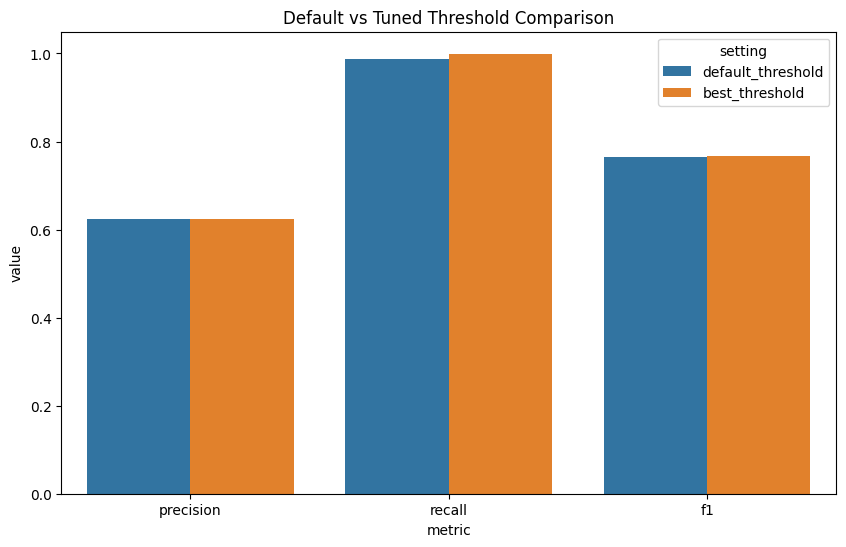

In [150]:
# Plot threshold comparison
threshold_compare_plot = threshold_comparison_df.reset_index().rename(columns={"index": "setting"})
threshold_compare_plot = threshold_compare_plot.melt(
    id_vars=["setting", "threshold"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=threshold_compare_plot, x="metric", y="value", hue="setting")
plt.title("Default vs Tuned Threshold Comparison")
plt.show()

In [151]:
# Print classification report at tuned threshold
print(classification_report(y_fe_test, y_pred_best_threshold))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86      4240
           1       0.62      1.00      0.77      1760

    accuracy                           0.82      6000
   macro avg       0.81      0.87      0.81      6000
weighted avg       0.89      0.82      0.83      6000

